# Motor-imagery EEG analysis pipeline

This notebook reproduces the numerical path used by the web application with an explicit 8–30 Hz band-pass filter and a 60 Hz notch filter. It loads PRE and POST rehabilitation recordings, prepares the EEG data, visualizes signals and power spectra with MNE, evaluates CSP-LDA and FBCSP-LDA, and compares the resulting accuracies with the supplied reference table.

> Goal: Develop a reproducible EEG analysis pipeline that quantifies changes in motor-imagery decoding performance before and after stroke rehabilitation.

The analysis measures decoding performance. It does not provide a clinical diagnosis or establish rehabilitation efficacy.

## 1. Setup

Run the notebook from the repository root or from `backend/app`. The setup cell finds the project root before importing application modules. Install the development dependencies with `python -m pip install -r backend/requirements-dev.txt`.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from html import escape
from pathlib import Path
import json
import sys

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import mne
import numpy as np
from IPython.display import HTML, JSON, display

mne.set_log_level("WARNING")

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "backend" / "app" / "main.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.app.domain.constants import CHANNEL_NAMES_16, CV_FOLDS
from backend.app.domain.types import EegDataset
from backend.app.evaluation.cross_validation import evaluate_cross_validation
from backend.app.evaluation.metrics import evaluate_holdout
from backend.app.models.csp import apply_csp, fit_csp
from backend.app.models.fbcsp import build_fbcsp_features
from backend.app.presentation.serializers import build_analysis_response
from backend.app.processing.artifacts import apply_optional_autoreject
from backend.app.processing.channels import select_channels
from backend.app.processing.filters import (
    apply_bandpass,
    apply_notch,
    crop_epochs,
    normalize_from_training,
)
from backend.app.processing.loaders import load_mat

print(f"Repository: {PROJECT_ROOT.name}")

Repository: stroke-rehab-web


## 2. Configuration

The web pipeline and this notebook share the same processing and model functions. These notebook values intentionally override the web defaults requested for this experiment: 8–30 Hz band-pass and 60 Hz notch.

`DATA_ROOT` assumes that `training_data` and `test_data` are next to the repository directory. Change it if the MAT files are stored elsewhere.

In [2]:
DATA_ROOT = PROJECT_ROOT.parent
TRAINING_DIR = DATA_ROOT / "training_data"
TEST_DIR = DATA_ROOT / "test_data"
FIGURE_DIR = PROJECT_ROOT / "backend" / "app" / "ipynb_results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = ("P1", "P2", "P3")
STAGES = ("pre", "post")
SELECTED_SUBJECT = "P1"
SELECTED_STAGE = "pre"

BANDPASS_HZ = (8.0, 30.0)
NOTCH_HZ = (60.0,)
LOADED_TRIAL_DURATION_S = 8.0
EPOCH_WINDOW_S = (2.0, 6.0)
CSP_COMPONENTS = 4
FBCSP_K_BEST = 16
RANDOM_SEED = 42
USE_AUTOREJECT = False

# MNE expects EEG amplitudes in volts. The MAT values appear to use microvolts;
# confirm this scale against the dataset documentation before publication.
MNE_DISPLAY_SCALE_TO_VOLTS = 1e-6

print(f"Training directory: {TRAINING_DIR.name}")
print(f"Test directory: {TEST_DIR.name}")
print(f"Band-pass: {BANDPASS_HZ[0]:g}–{BANDPASS_HZ[1]:g} Hz")
print(f"Notch: {NOTCH_HZ[0]:g} Hz")

Training directory: training_data
Test directory: test_data
Band-pass: 8–30 Hz
Notch: 60 Hz


In [3]:
def dataset_paths(subject: str, stage: str) -> tuple[Path, Path]:
    training_path = TRAINING_DIR / f"{subject}_{stage}_training.mat"
    test_path = TEST_DIR / f"{subject}_{stage}_test.mat"
    return training_path, test_path

inventory = []
for subject in SUBJECTS:
    for stage in STAGES:
        training_path, test_path = dataset_paths(subject, stage)
        inventory.append({
            "subject": subject,
            "stage": stage,
            "training_file": training_path.name,
            "training_found": training_path.exists(),
            "test_file": test_path.name,
            "test_found": test_path.exists(),
        })

missing = [row for row in inventory if not row["training_found"] or not row["test_found"]]
if missing:
    raise FileNotFoundError(f"Missing EEG files: {missing}")

display(inventory)

[{'subject': 'P1',
  'stage': 'pre',
  'training_file': 'P1_pre_training.mat',
  'training_found': True,
  'test_file': 'P1_pre_test.mat',
  'test_found': True},
 {'subject': 'P1',
  'stage': 'post',
  'training_file': 'P1_post_training.mat',
  'training_found': True,
  'test_file': 'P1_post_test.mat',
  'test_found': True},
 {'subject': 'P2',
  'stage': 'pre',
  'training_file': 'P2_pre_training.mat',
  'training_found': True,
  'test_file': 'P2_pre_test.mat',
  'test_found': True},
 {'subject': 'P2',
  'stage': 'post',
  'training_file': 'P2_post_training.mat',
  'training_found': True,
  'test_file': 'P2_post_test.mat',
  'test_found': True},
 {'subject': 'P3',
  'stage': 'pre',
  'training_file': 'P3_pre_training.mat',
  'training_found': True,
  'test_file': 'P3_pre_test.mat',
  'test_found': True},
 {'subject': 'P3',
  'stage': 'post',
  'training_file': 'P3_post_training.mat',
  'training_found': True,
  'test_file': 'P3_post_test.mat',
  'test_found': True}]

## 3. Preprocessing

Each session uses the same functions as the API pipeline:

1. `load_mat` reads the BR41N.IO flat format or the supported legacy structure.
2. `select_channels` keeps the 16-channel motor-imagery montage.
3. `apply_notch` removes 60 Hz line noise.
4. `apply_bandpass` keeps 8–30 Hz activity.
5. `crop_epochs` selects 2–6 s after the trigger.
6. `normalize_from_training` applies training-set statistics to training and test data.

The loader keeps the complete 8 s trial so the FIR filters have enough samples before the 2–6 s crop. The 60 Hz notch is retained as requested, although the 30 Hz low-pass stage already removes frequencies around 60 Hz. AutoReject remains disabled by default so that the notebook matches a deterministic baseline. Set `USE_AUTOREJECT = True` after installing `autoreject` if artifact repair is part of the experiment.

In [4]:
@dataclass(frozen=True)
class PreparedSession:
    subject: str
    stage: str
    sampling_rate: float
    channel_names: list[str]
    raw_train: np.ndarray
    filtered_train_physical: np.ndarray
    filtered_train: np.ndarray
    filtered_test: np.ndarray
    train_labels: np.ndarray
    test_labels: np.ndarray
    autoreject: dict


def select_motor_channels(dataset: EegDataset) -> EegDataset:
    epochs, channel_names = select_channels(
        dataset.epochs, dataset.channel_names, CHANNEL_NAMES_16
    )
    return EegDataset(
        epochs=epochs,
        labels=dataset.labels,
        sampling_rate=dataset.sampling_rate,
        channel_names=channel_names,
    )


def preprocess_epochs(epochs: np.ndarray, sampling_rate: float) -> np.ndarray:
    notched = apply_notch(epochs, sampling_rate, frequencies=NOTCH_HZ)
    filtered = apply_bandpass(
        notched, sampling_rate, low=BANDPASS_HZ[0], high=BANDPASS_HZ[1]
    )
    return crop_epochs(
        filtered, sampling_rate, EPOCH_WINDOW_S[0], EPOCH_WINDOW_S[1]
    )


def prepare_session(subject: str, stage: str) -> PreparedSession:
    training_path, test_path = dataset_paths(subject, stage)
    training = select_motor_channels(
        load_mat(training_path.read_bytes(), training_path.name, LOADED_TRIAL_DURATION_S)
    )
    test = select_motor_channels(
        load_mat(test_path.read_bytes(), test_path.name, LOADED_TRIAL_DURATION_S)
    )

    if not np.isclose(training.sampling_rate, test.sampling_rate):
        raise ValueError(
            f"Sampling-rate mismatch for {subject} {stage}: "
            f"{training.sampling_rate} vs {test.sampling_rate}"
        )
    if training.channel_names != test.channel_names:
        raise ValueError(f"Channel mismatch for {subject} {stage}.")

    sampling_rate = training.sampling_rate
    raw_train = crop_epochs(
        training.epochs.copy(),
        sampling_rate,
        EPOCH_WINDOW_S[0],
        EPOCH_WINDOW_S[1],
    )
    filtered_train = preprocess_epochs(training.epochs, sampling_rate)
    filtered_test = preprocess_epochs(test.epochs, sampling_rate)

    (
        filtered_train,
        train_labels,
        filtered_test,
        test_labels,
        keep_train,
        _,
        autoreject,
    ) = apply_optional_autoreject(
        filtered_train,
        training.labels,
        filtered_test,
        test.labels,
        sampling_rate,
        training.channel_names,
        USE_AUTOREJECT,
        RANDOM_SEED,
    )

    raw_train = raw_train[keep_train]
    filtered_train_physical = filtered_train.copy()
    filtered_train, filtered_test = normalize_from_training(
        filtered_train, filtered_test
    )

    return PreparedSession(
        subject=subject,
        stage=stage,
        sampling_rate=sampling_rate,
        channel_names=training.channel_names,
        raw_train=raw_train,
        filtered_train_physical=filtered_train_physical,
        filtered_train=filtered_train,
        filtered_test=filtered_test,
        train_labels=train_labels,
        test_labels=test_labels,
        autoreject=autoreject,
    )


selected_session = prepare_session(SELECTED_SUBJECT, SELECTED_STAGE)
print(
    f"{selected_session.subject} {selected_session.stage}: "
    f"train={selected_session.filtered_train.shape}, "
    f"test={selected_session.filtered_test.shape}, "
    f"fs={selected_session.sampling_rate:g} Hz"
)

P1 pre: train=(80, 16, 1024), test=(80, 16, 1024), fs=256 Hz


## 4. Data visualization with MNE

The first figure shows filtered training epochs in MNE's signal browser. The second uses MNE's spectrum implementation to display the average PSD from 1 to 45 Hz. The model still receives the normalized arrays produced in the preprocessing section.

The MAT files do not encode an explicit voltage unit in the fields used by the loader. `MNE_DISPLAY_SCALE_TO_VOLTS` is therefore a display assumption that must be checked against the dataset documentation before reporting amplitudes.

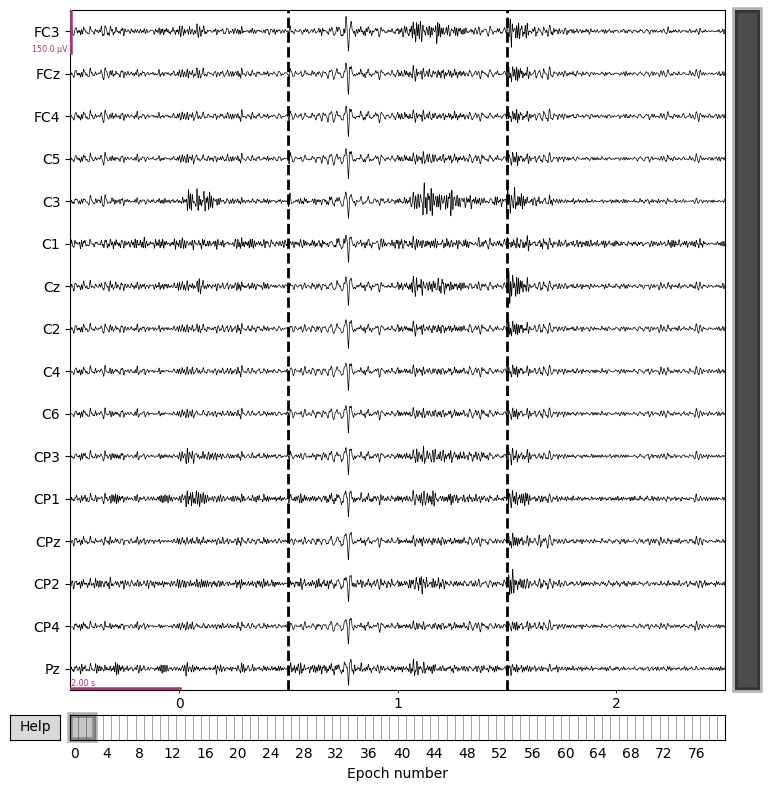

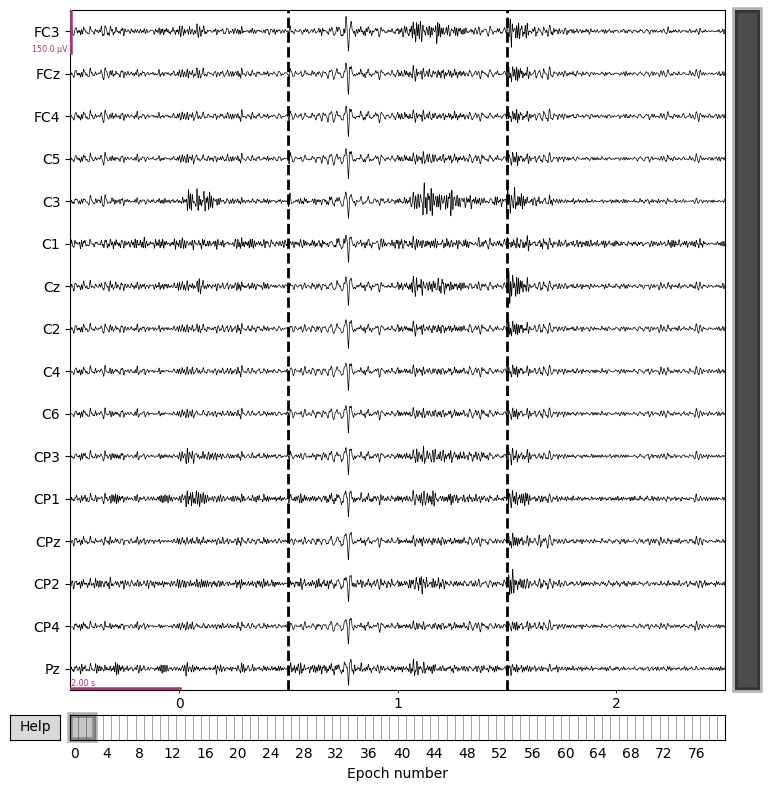

In [5]:
def as_mne_epochs(session: PreparedSession) -> mne.EpochsArray:
    info = mne.create_info(
        ch_names=session.channel_names,
        sfreq=session.sampling_rate,
        ch_types=["eeg"] * len(session.channel_names),
    )
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")
    event_codes = session.train_labels.astype(int) + 1
    events = np.column_stack([
        np.arange(event_codes.size, dtype=int),
        np.zeros(event_codes.size, dtype=int),
        event_codes,
    ])
    return mne.EpochsArray(
        session.filtered_train_physical * MNE_DISPLAY_SCALE_TO_VOLTS,
        info,
        events=events,
        event_id={"left_hand_imagery": 1, "right_hand_imagery": 2},
        tmin=EPOCH_WINDOW_S[0],
        baseline=None,
        verbose=False,
    )


mne_epochs = as_mne_epochs(selected_session)
signal_figure = mne_epochs.plot(
    n_epochs=3,
    n_channels=len(selected_session.channel_names),
    scalings={"eeg": 75e-6},
    title=f"{SELECTED_SUBJECT} {SELECTED_STAGE.upper()} | 8–30 Hz, 60 Hz notch",
    show=False,
)
signal_figure.savefig(
    FIGURE_DIR / f"01_{SELECTED_SUBJECT}_{SELECTED_STAGE}_mne_signals.png",
    dpi=180,
    bbox_inches="tight",
)
display(signal_figure)

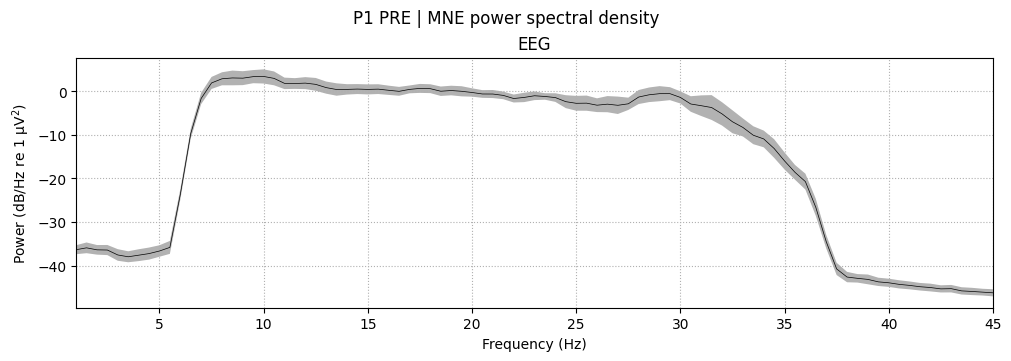

In [6]:
spectrum = mne_epochs.compute_psd(
    method="welch",
    fmin=1.0,
    fmax=45.0,
    n_fft=min(512, mne_epochs.get_data().shape[-1]),
    verbose=False,
)
psd_figure = spectrum.plot(
    average=True,
    picks="eeg",
    exclude="bads",
    show=False,
)
psd_figure.suptitle(
    f"{SELECTED_SUBJECT} {SELECTED_STAGE.upper()} | MNE power spectral density"
)
psd_figure.savefig(
    FIGURE_DIR / f"02_{SELECTED_SUBJECT}_{SELECTED_STAGE}_mne_psd.png",
    dpi=180,
    bbox_inches="tight",
)
display(psd_figure)

## 5. Models

CSP-LDA fits regularized Common Spatial Patterns, extracts normalized log-variance features, and classifies them with shrinkage Linear Discriminant Analysis.

FBCSP-LDA applies the project's filter bank, fits CSP inside each valid band, selects features with ANOVA, adds a broadband CSP branch, standardizes from training data, and uses the same shrinkage LDA classifier. Feature extraction and selection are fitted from training data within each holdout or cross-validation split.

In [7]:
def evaluate_session(session: PreparedSession) -> dict:
    trial_seconds = session.filtered_train.shape[-1] / session.sampling_rate
    component_count = int(np.clip(
        CSP_COMPONENTS,
        2,
        min(session.filtered_train.shape[1] - 1, 8),
    ))

    csp_filters = fit_csp(
        session.filtered_train, session.train_labels, component_count
    )
    csp_train = apply_csp(session.filtered_train, csp_filters)
    csp_test = apply_csp(session.filtered_test, csp_filters)
    csp_holdout = evaluate_holdout(
        csp_train,
        session.train_labels,
        csp_test,
        session.test_labels,
        trial_seconds,
    )

    fbcsp_train, fbcsp_test = build_fbcsp_features(
        session.filtered_train,
        session.train_labels,
        session.filtered_test,
        session.sampling_rate,
        component_count,
        FBCSP_K_BEST,
    )
    if fbcsp_train is None or fbcsp_test is None:
        raise RuntimeError("No valid FBCSP bands were available for this session.")
    fbcsp_holdout = evaluate_holdout(
        fbcsp_train,
        session.train_labels,
        fbcsp_test,
        session.test_labels,
        trial_seconds,
    )

    all_epochs = np.concatenate(
        [session.filtered_train, session.filtered_test], axis=0
    )
    all_labels = np.concatenate(
        [session.train_labels, session.test_labels], axis=0
    )
    csp_cross_validation = evaluate_cross_validation(
        all_epochs,
        all_labels,
        trial_seconds,
        RANDOM_SEED,
        "csp",
        component_count,
        session.sampling_rate,
        FBCSP_K_BEST,
    )
    fbcsp_cross_validation = evaluate_cross_validation(
        all_epochs,
        all_labels,
        trial_seconds,
        RANDOM_SEED,
        "fbcsp",
        component_count,
        session.sampling_rate,
        FBCSP_K_BEST,
    )

    response = build_analysis_response(
        raw_train=session.raw_train,
        filtered_train=session.filtered_train,
        filtered_test=session.filtered_test,
        sampling_rate=session.sampling_rate,
        channel_names=session.channel_names,
        csp_cross_validation=csp_cross_validation,
        fbcsp_cross_validation=fbcsp_cross_validation,
        csp_holdout=csp_holdout,
        fbcsp_holdout=fbcsp_holdout,
        autoreject=session.autoreject,
    )
    response["holdout"]["confusion"] = {
        "csp_lda": csp_holdout["confusion"],
        "fbcsp_lda": fbcsp_holdout["confusion"],
    }
    response["holdout"]["roc"] = {
        "csp_lda": csp_holdout["roc"],
        "fbcsp_lda": fbcsp_holdout["roc"],
    }
    response["holdout"]["evaluation"] = {
        "training_file": f"{session.subject}_{session.stage}_training.mat",
        "test_file": f"{session.subject}_{session.stage}_test.mat",
    }
    return response


selected_result = evaluate_session(selected_session)
display(JSON(selected_result))

<IPython.core.display.JSON object>

## 6. Training and evaluation protocols

The primary evaluation is a fixed training/test holdout. Each model fits `*_training.mat` and predicts `*_test.mat`, which matches the file structure in the supplied reference table. Accuracy, kappa, ROC-AUC, ROC curves, and confusion matrices in the main results section come from this holdout.

Five-fold stratified cross-validation is reported separately. It combines the training and test epochs and builds every feature pipeline again inside each fold. Holdout and cross-validation results must not be mixed in the same table or figure.

In [8]:
MODEL_LABELS = {"csp_lda": "CSP-LDA", "fbcsp_lda": "FBCSP-LDA"}
CLASS_LABELS = ("Left hand", "Right hand")

def save_table_figure(
    headers: tuple[str, ...],
    rows: list[list[str]],
    filename: str,
    title: str,
    figsize: tuple[float, float],
) -> Path:
    figure, axis = plt.subplots(figsize=figsize)
    axis.axis("off")
    table = axis.table(
        cellText=rows,
        colLabels=headers,
        cellLoc="center",
        colLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.45)
    for column_index in range(len(headers)):
        table[(0, column_index)].set_facecolor("#DCE6F1")
        table[(0, column_index)].set_height(0.10)
        table[(0, column_index)].set_text_props(weight="bold")
    axis.set_title(title, fontsize=13, fontweight="bold", pad=16)
    output_path = FIGURE_DIR / filename
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    display(figure)
    plt.close(figure)
    return output_path

def format_percent(value: float) -> str:
    return f"{value:.2f}%"

def format_kappa(value: float) -> str:
    return f"{value:.4f}"

In [9]:
def annotate_confusion_matrix(axis, matrix: np.ndarray, title: str) -> None:
    image = axis.imshow(matrix, cmap="Blues", vmin=0)
    threshold = matrix.max() / 2.0
    for expected_index in range(matrix.shape[0]):
        for predicted_index in range(matrix.shape[1]):
            value = int(matrix[expected_index, predicted_index])
            axis.text(
                predicted_index,
                expected_index,
                value,
                ha="center",
                va="center",
                color="white" if value > threshold else "black",
                fontweight="bold",
            )
    axis.set(
        title=title,
        xlabel="Predicted class",
        ylabel="Expected class",
        xticks=(0, 1),
        yticks=(0, 1),
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
    )
    axis.figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

def plot_roc_curve(axis, roc: dict, metrics: dict, label: str, color: str) -> None:
    axis.plot(
        roc["fpr"],
        roc["tpr"],
        linewidth=2,
        color=color,
        label=f"{label}: AUC {metrics['roc_auc']:.3f}, Acc {metrics['accuracy']:.2f}%",
    )

## 7. Training/test holdout comparison

This cell runs the complete pipeline for all three subjects and both rehabilitation stages. Each holdout model learns from the training file and is evaluated once on the corresponding test file.

The reference values were transcribed from the supplied table. Compare our holdout CSP-LDA result with the reference CSP-LDA column. The PCA-TVLDA column is included as context and is not method-equivalent to FBCSP-LDA. Differences can come from preprocessing, epoch timing, channel handling, classifier details, or evaluation protocol.

In [10]:
REFERENCE_ACCURACY = {
    ("P1", "pre"): {"csp_lda": 77.10, "pca_tvlda": 92.90},
    ("P1", "post"): {"csp_lda": 93.90, "pca_tvlda": 97.00},
    ("P2", "pre"): {"csp_lda": 68.40, "pca_tvlda": 72.40},
    ("P2", "post"): {"csp_lda": 96.10, "pca_tvlda": 97.40},
    ("P3", "pre"): {"csp_lda": 74.40, "pca_tvlda": 93.60},
    ("P3", "post"): {"csp_lda": 79.70, "pca_tvlda": 100.00},
}

web_results = {(SELECTED_SUBJECT, SELECTED_STAGE): selected_result}

for subject in SUBJECTS:
    for stage in STAGES:
        key = (subject, stage)
        if key in web_results:
            continue
        print(f"Processing {subject} {stage}...", flush=True)
        session = prepare_session(subject, stage)
        web_results[key] = evaluate_session(session)

print("All subject-stage pairs completed.")

Processing P1 post...


Processing P2 pre...


Processing P2 post...


Processing P3 pre...


Processing P3 post...


All subject-stage pairs completed.


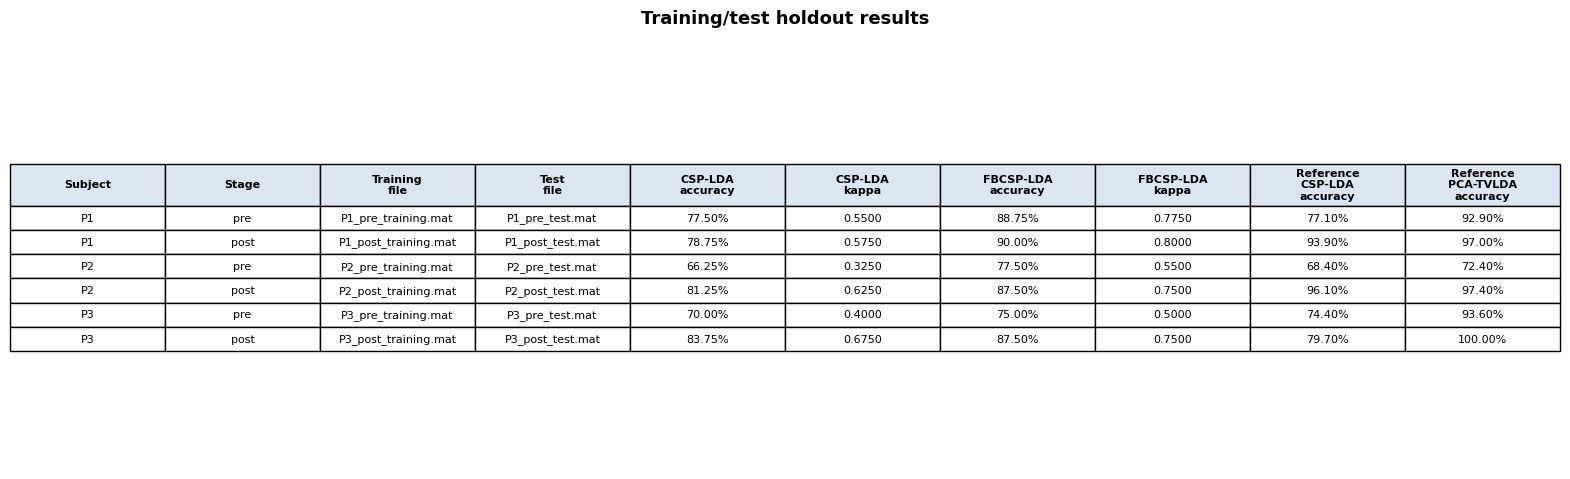

PosixPath('/Users/miguelisidrobaez/Desktop/Academico/Eventos/BR4IN.IO_2026/stroke-rehab/stroke-rehab-web/backend/app/ipynb_results/03_holdout_training_test_results.png')

In [11]:
comparison_rows = []
for subject in SUBJECTS:
    for stage in STAGES:
        key = (subject, stage)
        result = web_results[key]
        reference = REFERENCE_ACCURACY[key]
        csp_cv = result["metrics"]["csp_lda"]
        fbcsp_cv = result["metrics"]["fbcsp_lda"]
        csp_holdout = result["holdout"]["metrics"]["csp_lda"]
        fbcsp_holdout = result["holdout"]["metrics"]["fbcsp_lda"]
        comparison_rows.append({
            "subject": subject,
            "stage": stage,
            "csp_cv_accuracy": csp_cv["accuracy"],
            "csp_cv_auc": csp_cv["roc_auc"],
            "fbcsp_cv_accuracy": fbcsp_cv["accuracy"],
            "fbcsp_cv_auc": fbcsp_cv["roc_auc"],
            "csp_holdout_accuracy": csp_holdout["accuracy"],
            "csp_holdout_kappa": csp_holdout["kappa"],
            "fbcsp_holdout_accuracy": fbcsp_holdout["accuracy"],
            "fbcsp_holdout_kappa": fbcsp_holdout["kappa"],
            "csp_cv_kappa": csp_cv["kappa"],
            "fbcsp_cv_kappa": fbcsp_cv["kappa"],
            "reference_csp_accuracy": reference["csp_lda"],
            "csp_holdout_delta": csp_holdout["accuracy"] - reference["csp_lda"],
            "reference_pca_tvlda_accuracy": reference["pca_tvlda"],
        })

headers = (
    "Subject",
    "Stage",
    "Training file",
    "Test file",
    "CSP-LDA accuracy",
    "CSP-LDA kappa",
    "FBCSP-LDA accuracy",
    "FBCSP-LDA kappa",
    "Reference CSP-LDA accuracy",
    "Reference PCA-TVLDA accuracy",
)
figure_headers = (
    "Subject",
    "Stage",
    "Training\nfile",
    "Test\nfile",
    "CSP-LDA\naccuracy",
    "CSP-LDA\nkappa",
    "FBCSP-LDA\naccuracy",
    "FBCSP-LDA\nkappa",
    "Reference\nCSP-LDA\naccuracy",
    "Reference\nPCA-TVLDA\naccuracy",
)
fields = (
    "subject",
    "stage",
    "training_file",
    "test_file",
    "csp_holdout_accuracy",
    "csp_holdout_kappa",
    "fbcsp_holdout_accuracy",
    "fbcsp_holdout_kappa",
    "reference_csp_accuracy",
    "reference_pca_tvlda_accuracy",
)

def format_comparison_value(field: str, value: object) -> str:
    if field in {"subject", "stage", "training_file", "test_file"}:
        return escape(str(value))
    if "kappa" in field:
        return f"{float(value):.4f}"
    return f"{float(value):.2f}%"

holdout_by_key = {(row["subject"], row["stage"]): row for row in comparison_rows}
holdout_html_rows = []
for subject in SUBJECTS:
    for stage_index, stage in enumerate(STAGES):
        row = holdout_by_key[(subject, stage)]
        training_path, test_path = dataset_paths(subject, stage)
        for purpose_index, (purpose, path) in enumerate((("training", training_path), ("test", test_path))):
            cells = []
            if stage_index == 0 and purpose_index == 0:
                cells.append(f"<td rowspan='4'>{subject}</td>")
            if purpose_index == 0:
                cells.append(f"<td rowspan='2'>{stage}</td>")
            cells.extend((f"<td>{purpose}</td>", f"<td>{escape(path.name)}</td>"))
            if purpose_index == 0:
                cells.extend((
                    f"<td rowspan='2'>{row['csp_holdout_accuracy']:.2f}%</td>",
                    f"<td rowspan='2'>{row['csp_holdout_kappa']:.4f}</td>",
                    f"<td rowspan='2'>{row['fbcsp_holdout_accuracy']:.2f}%</td>",
                    f"<td rowspan='2'>{row['fbcsp_holdout_kappa']:.4f}</td>",
                    f"<td rowspan='2'>{row['reference_csp_accuracy']:.2f}%</td>",
                    f"<td rowspan='2'>{row['reference_pca_tvlda_accuracy']:.2f}%</td>",
                ))
            holdout_html_rows.append("<tr>" + "".join(cells) + "</tr>")

holdout_header = (
    "<thead><tr><th rowspan='2'>Subject</th><th rowspan='2'>Stage</th>"
    "<th rowspan='2'>Purpose</th><th rowspan='2'>File name</th>"
    "<th colspan='2'>CSP-LDA</th><th colspan='2'>FBCSP-LDA</th>"
    "<th colspan='2'>Reference accuracy</th></tr>"
    "<tr><th>Accuracy</th><th>Kappa</th><th>Accuracy</th><th>Kappa</th>"
    "<th>CSP-LDA</th><th>PCA-TVLDA</th></tr></thead>"
)
display(HTML("<div style='overflow-x:auto'><table>" + holdout_header + "<tbody>" + "".join(holdout_html_rows) + "</tbody></table></div>"))

holdout_figure_rows = []
for row in comparison_rows:
    training_path, test_path = dataset_paths(row["subject"], row["stage"])
    row["training_file"] = training_path.name
    row["test_file"] = test_path.name
    holdout_figure_rows.append([format_comparison_value(field, row[field]) for field in fields])
save_table_figure(figure_headers, holdout_figure_rows, "03_holdout_training_test_results.png", "Training/test holdout results", (20, 5.5))

## 8. Five-fold cross-validation

This table reports the separate five-fold stratified cross-validation protocol used by the web cards. Accuracy, kappa, and ROC-AUC are out-of-fold metrics over the combined training and test epochs. They are not the source of the holdout confusion matrices below.

Subject,Stage,CSP-LDA accuracy,CSP-LDA kappa,CSP-LDA AUC,FBCSP-LDA accuracy,FBCSP-LDA kappa,FBCSP-LDA AUC
P1,pre,85.62%,0.7125,0.9227,93.12%,0.8625,0.9798
P1,post,90.00%,0.8000,0.9489,94.38%,0.8875,0.9806
P2,pre,69.38%,0.3875,0.7591,80.62%,0.6125,0.8792
P2,post,76.88%,0.5375,0.8506,89.38%,0.7875,0.9584
P3,pre,82.50%,0.6500,0.8880,86.25%,0.7250,0.9302
P3,post,79.38%,0.5875,0.8931,89.38%,0.7875,0.9569


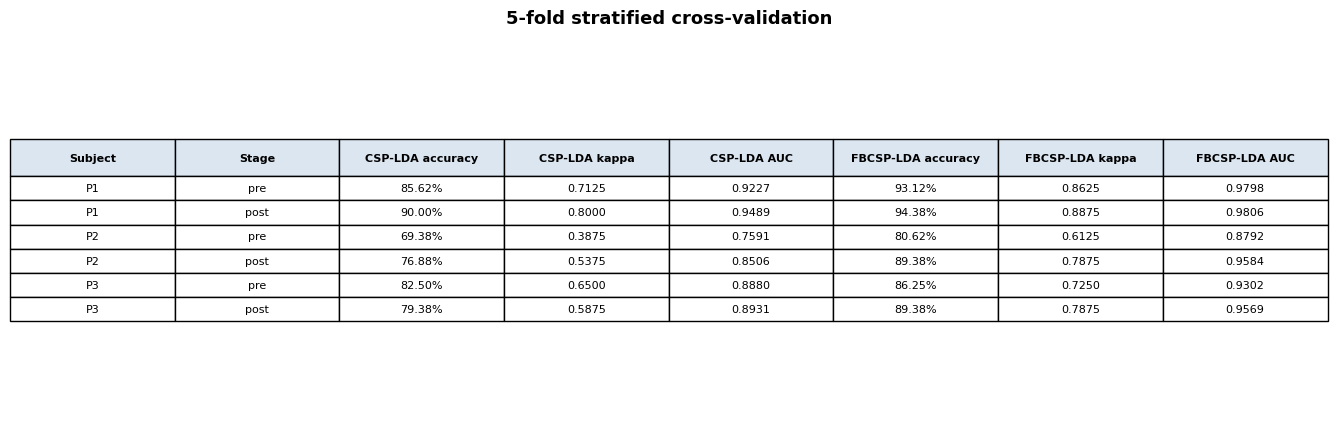

PosixPath('/Users/miguelisidrobaez/Desktop/Academico/Eventos/BR4IN.IO_2026/stroke-rehab/stroke-rehab-web/backend/app/ipynb_results/04_five_fold_cross_validation_results.png')

In [12]:
cv_headers = ("Subject", "Stage", "CSP-LDA accuracy", "CSP-LDA kappa", "CSP-LDA AUC", "FBCSP-LDA accuracy", "FBCSP-LDA kappa", "FBCSP-LDA AUC")
cv_figure_rows = []
cv_html_rows = []
for row in comparison_rows:
    values = [
        row["subject"],
        row["stage"],
        format_percent(row["csp_cv_accuracy"]),
        format_kappa(row["csp_cv_kappa"]),
        f"{row['csp_cv_auc']:.4f}",
        format_percent(row["fbcsp_cv_accuracy"]),
        format_kappa(row["fbcsp_cv_kappa"]),
        f"{row['fbcsp_cv_auc']:.4f}",
    ]
    cv_figure_rows.append(values)
    cv_html_rows.append("<tr>" + "".join(f"<td>{escape(value)}</td>" for value in values) + "</tr>")

display(HTML("<div style='overflow-x:auto'><table><thead><tr>" + "".join(f"<th>{escape(header)}</th>" for header in cv_headers) + "</tr></thead><tbody>" + "".join(cv_html_rows) + "</tbody></table></div>"))
save_table_figure(cv_headers, cv_figure_rows, "04_five_fold_cross_validation_results.png", f"{CV_FOLDS}-fold stratified cross-validation", (17, 4.8))

## 9. Holdout confusion matrices

These matrices use predictions from models fitted on each subject's training file and evaluated on the matching test file. They do not use five-fold cross-validation predictions. Each subject figure contains PRE and POST matrices for CSP-LDA and FBCSP-LDA.

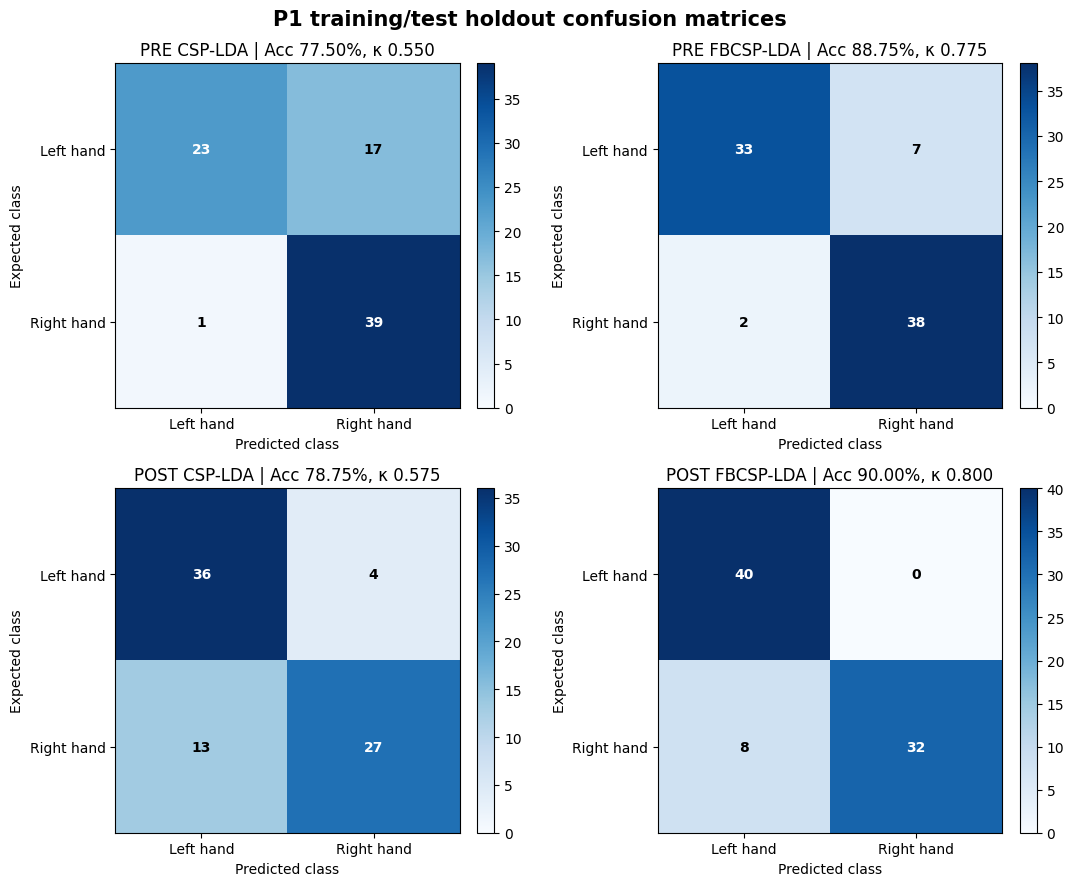

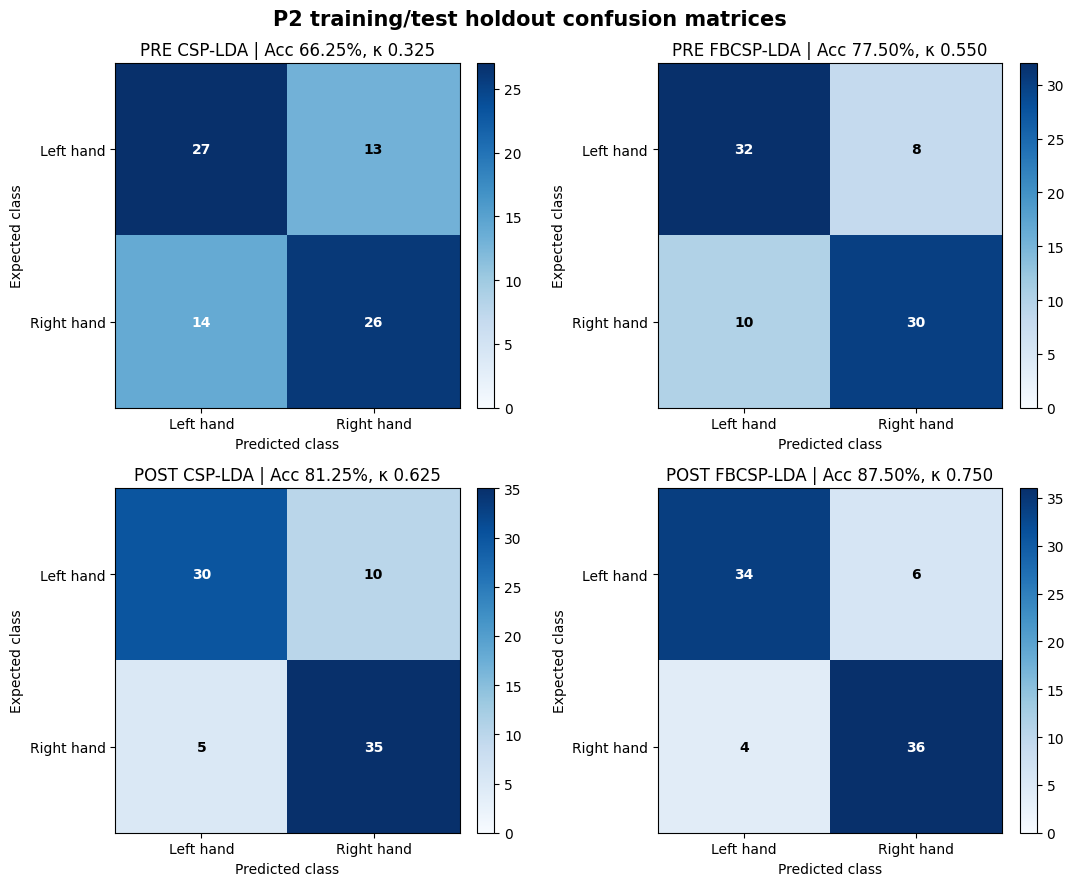

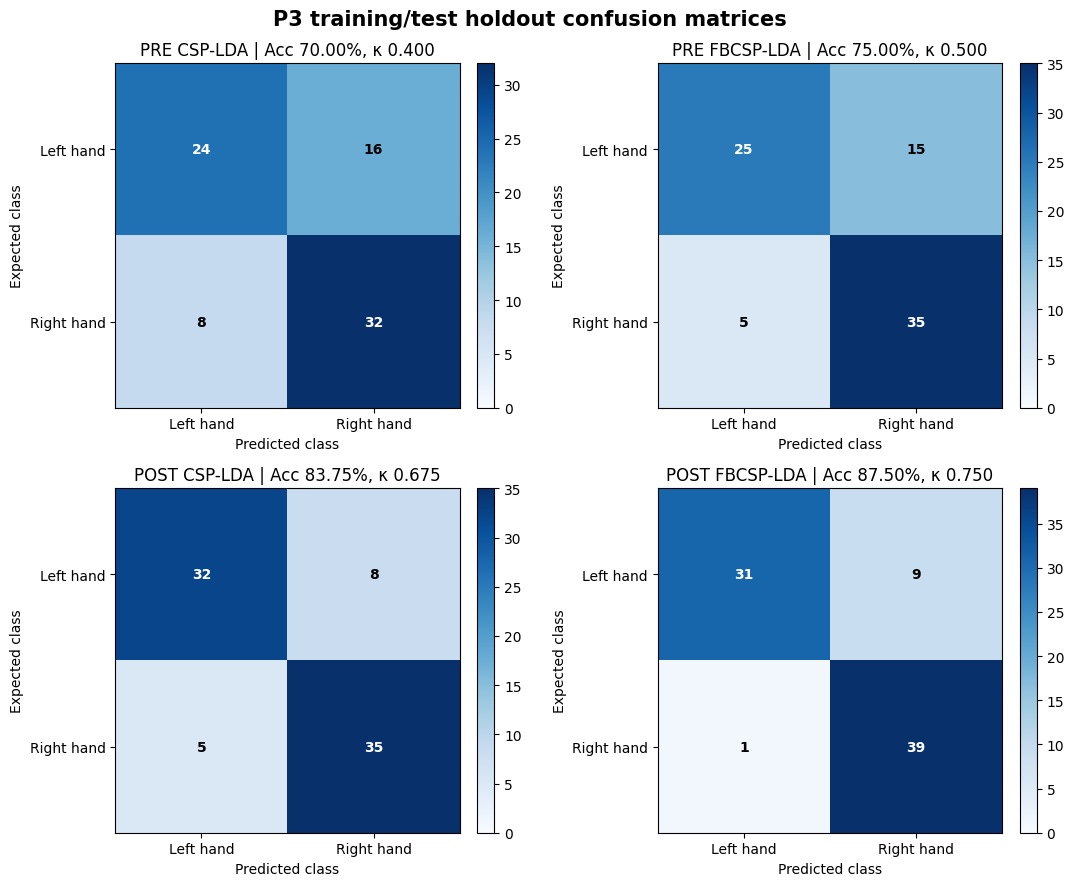

In [13]:
confusion_figure_paths = []
for subject_index, subject in enumerate(SUBJECTS):
    figure, axes = plt.subplots(2, 2, figsize=(11, 9))
    for stage_index, stage in enumerate(STAGES):
        result = web_results[(subject, stage)]
        for model_index, model_name in enumerate(("csp_lda", "fbcsp_lda")):
            matrix = np.asarray(result["holdout"]["confusion"][model_name])
            metrics = result["holdout"]["metrics"][model_name]
            annotate_confusion_matrix(
                axes[stage_index, model_index],
                matrix,
                f"{stage.upper()} {MODEL_LABELS[model_name]} | Acc {metrics['accuracy']:.2f}%, κ {metrics['kappa']:.3f}",
            )
    figure.suptitle(f"{subject} training/test holdout confusion matrices", fontsize=15, fontweight="bold")
    figure.tight_layout()
    output_path = FIGURE_DIR / f"{subject_index + 5:02d}_{subject}_holdout_confusion_matrices.png"
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    confusion_figure_paths.append(output_path)
    display(figure)
    plt.close(figure)

## 10. Holdout ROC curves

The ROC curves below use the same training/test holdout predictions as the confusion matrices. Each subject has one PRE panel and one POST panel with both models.

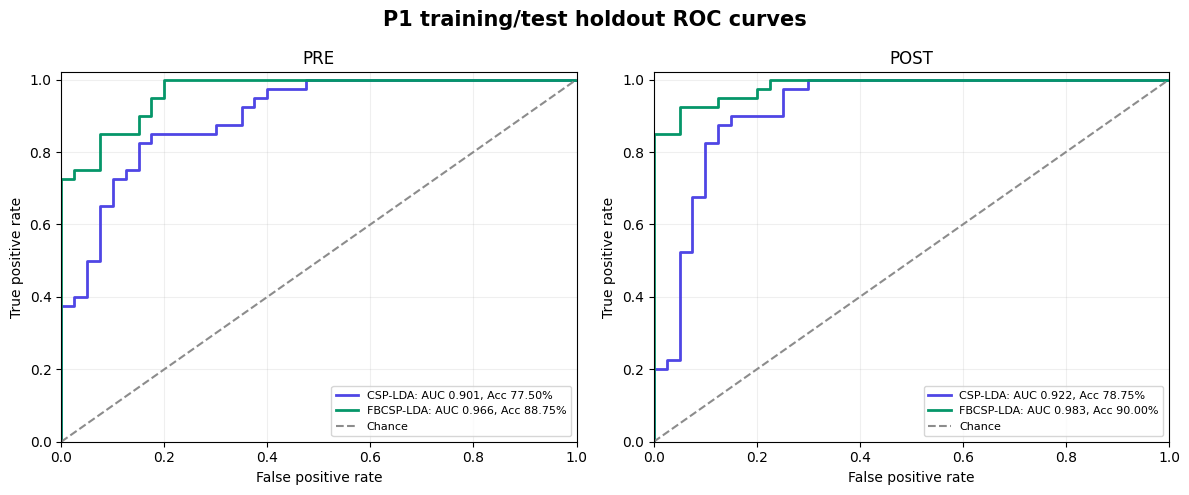

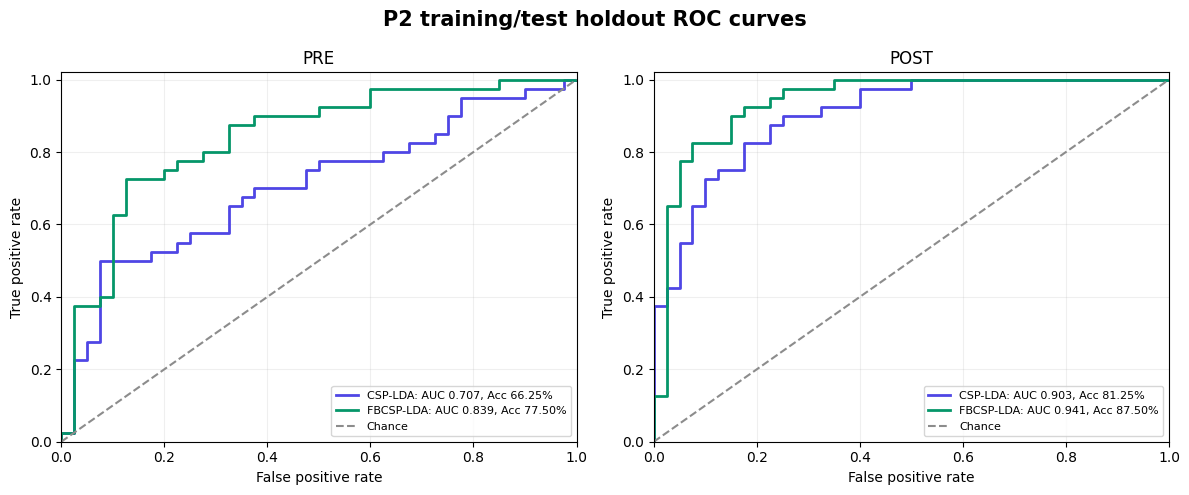

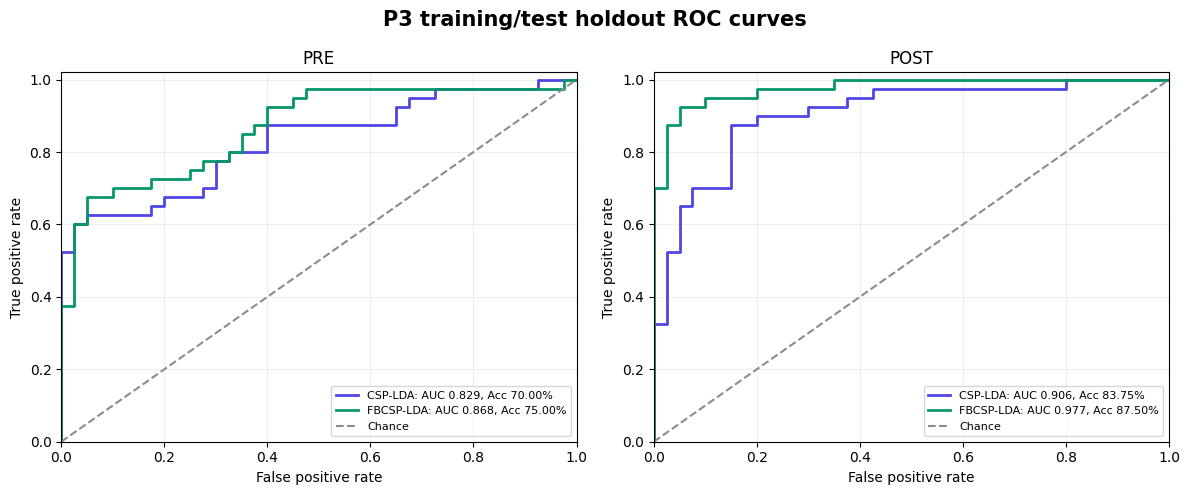

In [14]:
roc_figure_paths = []
model_colors = {"csp_lda": "#4F46E5", "fbcsp_lda": "#059669"}
for subject_index, subject in enumerate(SUBJECTS):
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    for stage_index, stage in enumerate(STAGES):
        result = web_results[(subject, stage)]
        axis = axes[stage_index]
        for model_name in ("csp_lda", "fbcsp_lda"):
            plot_roc_curve(
                axis,
                result["holdout"]["roc"][model_name],
                result["holdout"]["metrics"][model_name],
                MODEL_LABELS[model_name],
                model_colors[model_name],
            )
        axis.plot((0, 1), (0, 1), linestyle="--", color="0.55", label="Chance")
        axis.set(title=stage.upper(), xlabel="False positive rate", ylabel="True positive rate", xlim=(0, 1), ylim=(0, 1.02))
        axis.grid(alpha=0.2)
        axis.legend(loc="lower right", fontsize=8)
    figure.suptitle(f"{subject} training/test holdout ROC curves", fontsize=15, fontweight="bold")
    figure.tight_layout()
    output_path = FIGURE_DIR / f"{subject_index + 8:02d}_{subject}_holdout_roc_curves.png"
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    roc_figure_paths.append(output_path)
    display(figure)
    plt.close(figure)

## 11. PRE to POST holdout changes

Positive values indicate higher POST performance on the held-out test file. Report the PRE and POST values with each change. A change in decoding performance does not establish a clinical outcome.

Subject,Model,PRE accuracy,POST accuracy,Accuracy change,PRE kappa,POST kappa,Kappa change
P1,CSP-LDA,77.50%,78.75%,+1.25 pp,0.5500,0.5750,+0.0250
P1,FBCSP-LDA,88.75%,90.00%,+1.25 pp,0.7750,0.8000,+0.0250
P2,CSP-LDA,66.25%,81.25%,+15.00 pp,0.3250,0.6250,+0.3000
P2,FBCSP-LDA,77.50%,87.50%,+10.00 pp,0.5500,0.7500,+0.2000
P3,CSP-LDA,70.00%,83.75%,+13.75 pp,0.4000,0.6750,+0.2750
P3,FBCSP-LDA,75.00%,87.50%,+12.50 pp,0.5000,0.7500,+0.2500


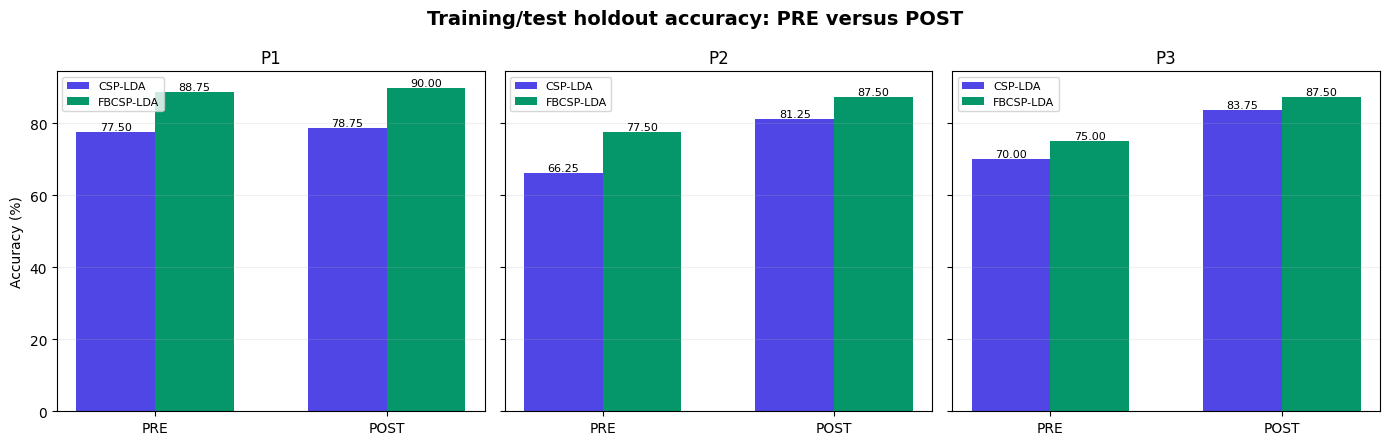

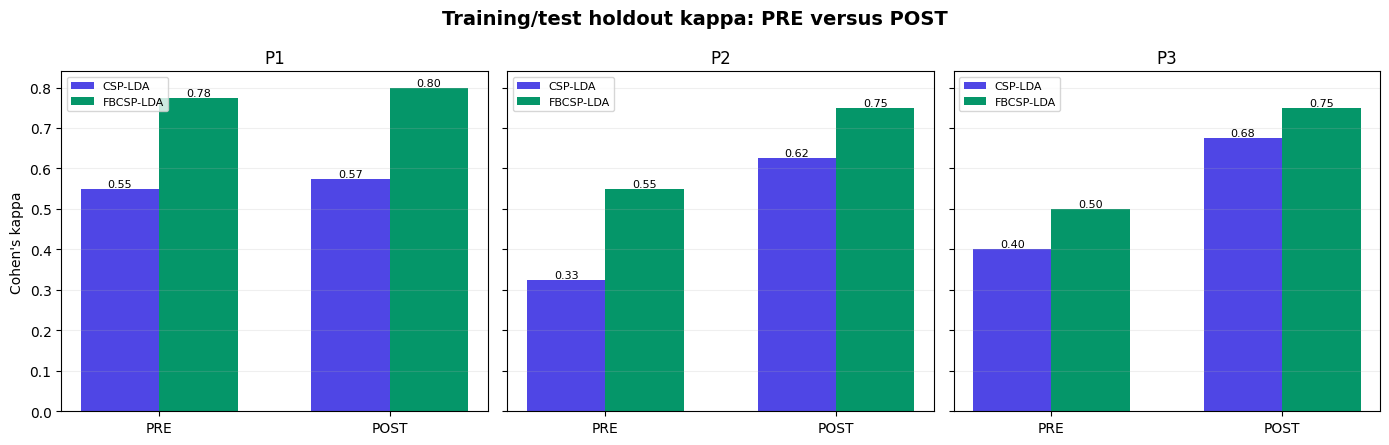

In [15]:
change_headers = ("Subject", "Model", "PRE accuracy", "POST accuracy", "Accuracy change", "PRE kappa", "POST kappa", "Kappa change")
change_rows = []
change_html_rows = []
for subject in SUBJECTS:
    for model_name in ("csp_lda", "fbcsp_lda"):
        pre_metrics = web_results[(subject, "pre")]["holdout"]["metrics"][model_name]
        post_metrics = web_results[(subject, "post")]["holdout"]["metrics"][model_name]
        values = [
            subject,
            MODEL_LABELS[model_name],
            format_percent(pre_metrics["accuracy"]),
            format_percent(post_metrics["accuracy"]),
            f"{post_metrics['accuracy'] - pre_metrics['accuracy']:+.2f} pp",
            format_kappa(pre_metrics["kappa"]),
            format_kappa(post_metrics["kappa"]),
            f"{post_metrics['kappa'] - pre_metrics['kappa']:+.4f}",
        ]
        change_rows.append(values)
        change_html_rows.append("<tr>" + "".join(f"<td>{escape(value)}</td>" for value in values) + "</tr>")
display(HTML("<table><thead><tr>" + "".join(f"<th>{escape(header)}</th>" for header in change_headers) + "</tr></thead><tbody>" + "".join(change_html_rows) + "</tbody></table>"))

def plot_pre_post_metric(metric_name: str, ylabel: str, filename: str) -> Path:
    figure, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
    x_positions = np.arange(len(STAGES))
    width = 0.34
    for subject_index, subject in enumerate(SUBJECTS):
        axis = axes[subject_index]
        for model_index, model_name in enumerate(("csp_lda", "fbcsp_lda")):
            values = [web_results[(subject, stage)]["holdout"]["metrics"][model_name][metric_name] for stage in STAGES]
            offset = (model_index - 0.5) * width
            axis.bar(x_positions + offset, values, width, label=MODEL_LABELS[model_name], color=model_colors[model_name])
            for position, value in zip(x_positions + offset, values):
                axis.text(position, value, f"{value:.2f}", ha="center", va="bottom", fontsize=8)
        axis.set(title=subject, xticks=x_positions, xticklabels=("PRE", "POST"), ylabel=ylabel if subject_index == 0 else "")
        axis.grid(axis="y", alpha=0.2)
        axis.legend(fontsize=8)
    figure.suptitle(f"Training/test holdout {metric_name}: PRE versus POST", fontsize=14, fontweight="bold")
    figure.tight_layout()
    output_path = FIGURE_DIR / filename
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    display(figure)
    plt.close(figure)
    return output_path

accuracy_change_path = plot_pre_post_metric("accuracy", "Accuracy (%)", "11_pre_post_holdout_accuracy.png")
kappa_change_path = plot_pre_post_metric("kappa", "Cohen's kappa", "12_pre_post_holdout_kappa.png")

## 12. Generated figure files

All analysis figures and the presentation-ready pipeline schematic are stored under `backend/app/ipynb_results`. The list below is generated from that directory after the analysis finishes.

In [16]:
generated_figures = sorted(FIGURE_DIR.glob("*.png"))
if len(generated_figures) != 13:
    raise RuntimeError(f"Expected 13 project figures, found {len(generated_figures)}.")
display(HTML("<ul>" + "".join(f"<li><code>{escape(path.name)}</code></li>" for path in generated_figures) + "</ul>"))

## 13. Manual review and next work

Before using these results in the hackathon presentation or a report:

- Confirm the EEG amplitude unit and update `MNE_DISPLAY_SCALE_TO_VOLTS` if needed.
- Cite the source of the reference CSP-LDA and PCA-TVLDA accuracies.
- Confirm whether the reference used holdout testing or cross-validation.
- Verify the trigger-to-class mapping for left- and right-hand imagery.
- Decide whether AutoReject belongs in the final protocol, then keep that choice fixed for PRE and POST sessions.
- Add confidence intervals or a permutation analysis before interpreting small PRE/POST differences.
- Record package versions, dataset checksums, and the final Git commit for the reproducibility report.

Add team decisions and experiment notes below this cell so the notebook remains the executable record of the analysis.